# EDA - Right Home

## INTRO: Om denna EDA
Denna analys undersöker bostadsdata för tre svenska städer. Stockholm, Malmö och Göteborg. Datan är genererad och processad via vår ETL-pipeline (ETL_Pipline) och innehåller information om priser, bostadstyper, upplåtelseformer och geografisk placering.

Analysen är uppdelad i:
1. Datainladdning och joins via DuckDB
2. Datakvalitetskontroll
3. Outlier-analys och rensning
4. Och sist men inte minst, Data Storytelling — tre matplotlib-grafer med insikter


### Värt att notera: Koden och datan har uppdaterats, samt EDA:n.

## 1. Imports & Setup

In [50]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

GRAY_1 = "#aaaaaa"
GRAY_2 = "#888888"
GRAY_3 = "#444444"
HIGHLIGHT = "#E07B54"
BASE_COLOR = "#bbbbbb"

## 2. Data med DuckDB

In [51]:
df_bostader  = pd.read_csv('../ETL_Pipline/bostader.csv')
df_priser    = pd.read_csv('../ETL_Pipline/priser.csv')
df_platser   = pd.read_csv('../ETL_Pipline/platser.csv')
df_visningar = pd.read_csv('../ETL_Pipline/visningar.csv')

con = duckdb.connect()
con.register('bostader',  df_bostader)
con.register('priser',    df_priser)
con.register('platser',   df_platser)
con.register('visningar', df_visningar)

print('Tabeller inlasta:')
print(f'  bostader:  {len(df_bostader)} rader')
print(f'  priser:    {len(df_priser)} rader')
print(f'  platser:   {len(df_platser)} rader')
print(f'  visningar: {len(df_visningar)} rader')

Tabeller inlasta:
  bostader:  1000 rader
  priser:    1000 rader
  platser:   20 rader
  visningar: 2 rader


## 3. Joina tabeller med hjälp av DuckDB

In [52]:
query = """
    SELECT *
    FROM bostader b
    JOIN priser    p  ON b.id       = p.bostad_id
    JOIN platser   pl ON b.plats_id = pl.plats_id
"""

df = con.execute(query).df()
df['created_at'] = pd.to_datetime(df['created_at'])
print(f'Sammanfogad tabell: {df.shape[0]} rader, {df.shape[1]} kolumner')
df.head()

Sammanfogad tabell: 1000 rader, 31 kolumner


,id,typ,upplåtelseform,rum,boyta,boyta_enhet,tillgänglig,created_at,adress,lat,...,pris,avgift,kvadratmeterpris,pris_per_kvm,valuta,manadskostnad,område,stad,plats_id_1,kommun_befolkning
0,1,hus,köpa,5,120,m²,True,2026-01-04,Bergsgatan 36,59.31848,...,10587543,3293,88229,88230.0,SEK,52039,Södermalm,Stockholm,1,995574
1,2,lägenhet,köpa,6,144,m²,True,2025-05-24,Parkvägen 78,55.56498,...,4447103,9411,30882,30883.0,SEK,29886,Hyllie,Malmö,2,365644
2,3,lägenhet,köpa,4,96,m²,False,2025-11-06,Kungsgatan 81,55.59328,...,2203192,5059,22949,22950.0,SEK,15202,Rosengård,Malmö,3,365644
3,4,lägenhet,köpa,4,76,m²,False,2025-05-30,Lindvägen 66,59.34106,...,7325734,4756,96391,96391.0,SEK,38484,Vasastan,Stockholm,4,995574
4,5,lägenhet,köpa,3,78,m²,True,2025-10-12,Skolvägen 117,59.31236,...,6662306,5594,85414,85414.0,SEK,36268,Nacka,Stockholm,5,995574


## 4. Datakvalitet - Kvalitetskontroll

In [53]:
print('=== Datatyper & null-värden ===')
print(df.info())

=== Datatyper & null-värden ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     1000 non-null   int64         
 1   typ                    1000 non-null   str           
 2   upplåtelseform         1000 non-null   str           
 3   rum                    1000 non-null   int64         
 4   boyta                  1000 non-null   int64         
 5   boyta_enhet            1000 non-null   str           
 6   tillgänglig            1000 non-null   bool          
 7   created_at             1000 non-null   datetime64[us]
 8   adress                 1000 non-null   str           
 9   lat                    1000 non-null   float64       
 10  lon                    1000 non-null   float64       
 11  plats_id               1000 non-null   int64         
 12  sparad                 1000 non-null   int

In [54]:
display(df[['pris', 'avgift', 'rum', 'boyta', 'pris_per_kvm']].describe().round(0))

,pris,avgift,rum,boyta,pris_per_kvm
count,1000.0,1000.0,1000.0,1000.0,1000.0
mean,3608014.0,2846.0,4.0,81.0,44760.0
std,3506959.0,2365.0,2.0,40.0,33406.0
min,2329.0,0.0,1.0,18.0,120.0
25%,656893.0,1097.0,2.0,48.0,21584.0
50%,2877566.0,2648.0,3.0,80.0,44502.0
75%,5364515.0,3972.0,5.0,112.0,63016.0
max,19868269.0,12345.0,6.0,168.0,142574.0


In [55]:
print(f'Antal dubletter (på id): {df.duplicated(subset=["id"]).sum()}')
print(f'\nFördelning per stad:')
print(df['stad'].value_counts())
print(f'\nBostadstyper:')
print(df['typ'].value_counts())
print(f'\nUpplåtelseformer:')
print(df['upplåtelseform'].value_counts())

Antal dubletter (på id): 0

Fördelning per stad:
stad
Malmö        339
Stockholm    334
Göteborg     327
Name: count, dtype: int64

Bostadstyper:
typ
lägenhet    508
hus         492
Name: count, dtype: int64

Upplåtelseformer:
upplåtelseform
köpa    761
hyra    239
Name: count, dtype: int64


**Datakvalitet (Observationer):** Datan innehåller inga dubletter och inga null-värden i någon av kolumnerna. Fördelningen per stad är relativt jämn, Malmö (339), Stockholm (334) och Göteborg (327), något som även kan skilja sig efter nya laddade/genererade datan. Lägenhet är något vanligare än hus (508 vs 492), köpa dominerar över hyra (761 vs 239).

## 5. Outlier-analys - DuckDB

In [56]:
outliers = con.execute("""
    SELECT id, stad, område, boyta, pris, pris_per_kvm
    FROM df
    WHERE pris_per_kvm > 120000
       OR pris_per_kvm < 5000
       OR boyta < 20
    ORDER BY pris_per_kvm DESC
""").df()

print(f'Potentiella outliers: {len(outliers)} st')
display(outliers)

Potentiella outliers: 275 st


,id,stad,område,boyta,pris,pris_per_kvm
0,213,Stockholm,Östermalm,100,14257391,142574.0
1,957,Stockholm,Östermalm,112,15926365,142200.0
2,579,Stockholm,Östermalm,140,19868269,141916.0
3,932,Stockholm,Östermalm,44,6242821,141882.0
4,622,Stockholm,Östermalm,120,16989690,141581.0
...,...,...,...,...,...,...
270,216,Malmö,Hyllie,72,8677,121.0
271,753,Stockholm,Östermalm,168,20292,121.0
272,670,Malmö,Hyllie,95,11419,120.0
273,742,Göteborg,Centrum,125,15047,120.0


In [57]:
df_clean = con.execute("""
    SELECT * FROM df
    WHERE pris_per_kvm BETWEEN 5000 AND 120000
    AND boyta >= 20
""").df()

städer_i_data = sorted(df_clean['stad'].unique())
print(f'Rader efter filtrering: {len(df_clean)} (borttagna: {len(df) - len(df_clean)})')
print(f'Städer i datan: {städer_i_data}')

Rader efter filtrering: 725 (borttagna: 275)
Städer i datan: ['Göteborg', 'Malmö', 'Stockholm']


**Outlier-hantering (Observationer):** 275 rader filtrerades bort med pris_per_kvm utanför intervallet 5 000–120 000 kr eller boyta under 20 m². Det rensade datasetet innehåller 725 rader och används för all vidare analys. Som tidigare nämnt, även här så är det något som kan skilja sig efter nya laddade/genererade datan på förfrågan.

## 6. Data Storytelling – Graf 1
### Varför kostar Stockholm dubbelt så mycket per kvadratmeter?

Grafen ska jämföra den genomsnittliga pris per kvm per stad. Frågan lyder så här — vad gör Stockholm annorlunda?

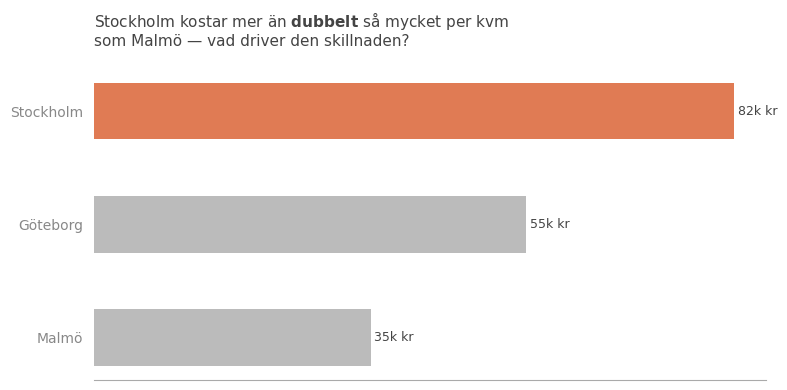

In [61]:
agg = (
    df_clean
    .groupby('stad')['pris_per_kvm']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

# Highlighta Stockholm, gråar ut resten
colors = [HIGHLIGHT if s == 'Stockholm' else BASE_COLOR for s in agg['stad']]

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(agg['stad'], agg['pris_per_kvm'] / 1000,
               color=colors, height=0.5)

# Värdelabels
for bar, val in zip(bars, agg['pris_per_kvm']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val/1000:.0f}k kr', va='center', fontsize=9, color=GRAY_3)

# Tar bort grid och spines
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color(GRAY_1)
ax.xaxis.set_visible(False)

# Dämpar tick-labels
ax.tick_params(axis='y', colors=GRAY_2, labelsize=10, length=0, pad=8)

# Storytelling titel
ax.set_title(
    'Stockholm kostar mer än ' + r'$\bf{dubbelt}$' + ' så mycket per kvm\n'
    'som Malmö — vad driver den skillnaden?',
    loc='left', color=GRAY_3, fontsize=11, pad=16
)

fig.tight_layout()
plt.show()


## 7. Data Storytelling – Graf 2
### Stockholm-bostäder är dyra oavsett storlek

Boyta mot pris. Återigen highlightas Stockholm, medan övriga städer tonas ner. Detta är för att verkligen visa att Stockholm faktiskt håller i sig oavsett hur stor bostaden är.

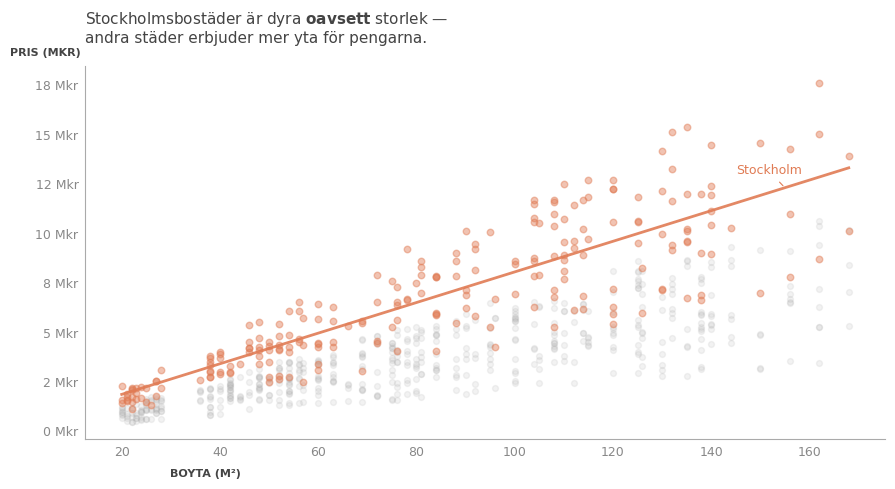

In [59]:
fig, ax = plt.subplots(figsize=(9, 5))

# Övriga städer först (grå, bakgrund)
for stad in städer_i_data:
    if stad == 'Stockholm':
        continue
    subset = df_clean[df_clean['stad'] == stad]
    ax.scatter(subset['boyta'], subset['pris'] / 1_000_000,
               alpha=0.15, s=18, color=GRAY_1)

# Stockholm highlightad ovanpå
sthlm = df_clean[df_clean['stad'] == 'Stockholm']
ax.scatter(sthlm['boyta'], sthlm['pris'] / 1_000_000,
           alpha=0.45, s=22, color=HIGHLIGHT, label='Stockholm')

# En trendlinje bara för Stockholm
z = sthlm[['boyta', 'pris']].dropna()
coef = np.polyfit(z['boyta'], z['pris'], 1)
xs = np.linspace(z['boyta'].min(), z['boyta'].max(), 100)
ax.plot(xs, np.polyval(coef, xs) / 1_000_000,
        color=HIGHLIGHT, linewidth=2, alpha=0.9)

# Tar bort legend, för annotation
ax.annotate('Stockholm', xy=(155, np.polyval(coef, 155) / 1_000_000),
            xytext=(145, 13), color=HIGHLIGHT, fontsize=9,
            arrowprops=dict(arrowstyle='-', color=HIGHLIGHT, lw=0.8))

# Spines
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRAY_1)
ax.tick_params(axis='both', colors=GRAY_2, labelsize=9, length=0, pad=5)

ax.set_xlabel('BOYTA (M²)', color=GRAY_3, fontsize=8, fontweight='bold')
ax.set_ylabel('PRIS (MKR)', color=GRAY_3, fontsize=8, fontweight='bold', rotation=0)
ax.yaxis.set_label_coords(-0.05, 1.02)
ax.xaxis.set_label_coords(0.15, -0.08)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f} Mkr'))

ax.set_title(
    'Stockholmsbostäder är dyra ' + r'$\bf{oavsett}$' + ' storlek —\n'
    'andra städer erbjuder mer yta för pengarna.',
    loc='left', color=GRAY_3, fontsize=11, pad=16
)

fig.tight_layout()
plt.show()


## 8. Data Storytelling – Graf 3
### Stabil prisnivå i Stockholm — i Malmö och Göteborg svänger det mer

Line chart med prisutveckling per månad.

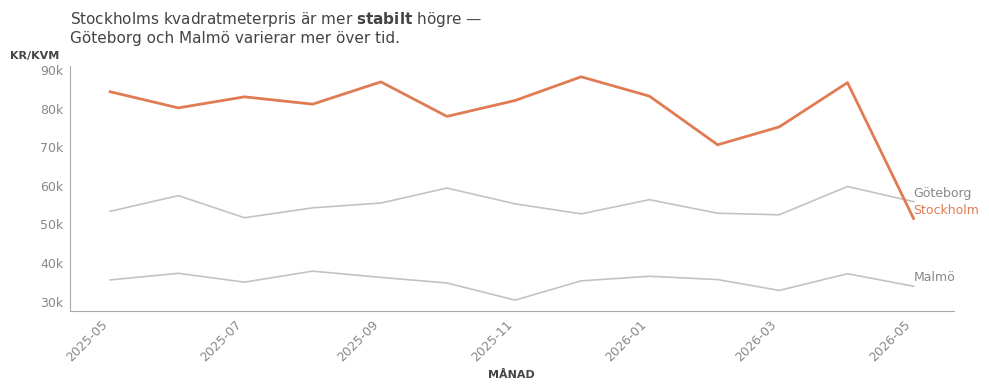

In [62]:
df_trend = df_clean.copy()
df_trend['created_at'] = pd.to_datetime(df_trend['created_at'])
df_trend['månad'] = df_trend['created_at'].dt.to_period('M')

trend = (
    df_trend
    .groupby(['månad', 'stad'])['pris_per_kvm']
    .mean()
    .reset_index()
)
trend['månad_dt'] = trend['månad'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(10, 4))

for stad in städer_i_data:
    data = trend[trend['stad'] == stad].sort_values('månad_dt')
    if stad == 'Stockholm':
        ax.plot(data['månad_dt'], data['pris_per_kvm'] / 1000,
                linewidth=2, color=HIGHLIGHT, zorder=3)
        # Label direkt på linjen
        last = data.iloc[-1]
        ax.text(last['månad_dt'], last['pris_per_kvm'] / 1000 + 0.5,
                'Stockholm', color=HIGHLIGHT, fontsize=9, va='bottom')
    else:
        ax.plot(data['månad_dt'], data['pris_per_kvm'] / 1000,
                linewidth=1.2, color=GRAY_1, zorder=2, alpha=0.7)
        last = data.iloc[-1]
        ax.text(last['månad_dt'], last['pris_per_kvm'] / 1000 + 0.5,
                stad, color=GRAY_2, fontsize=9, va='bottom')

# Spines
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(GRAY_1)
ax.tick_params(axis='both', colors=GRAY_2, labelsize=9, length=0, pad=5)
plt.xticks(rotation=45, ha='right')

ax.set_xlabel('MÅNAD', color=GRAY_3, fontsize=8, fontweight='bold')
ax.set_ylabel('KR/KVM', color=GRAY_3, fontsize=8, fontweight='bold', rotation=0)
ax.yaxis.set_label_coords(-0.04, 1.02)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}k'))

ax.set_title(
    'Stockholms kvadratmeterpris är mer ' + r'$\bf{stabilt}$' + ' högre —\n'
    'Göteborg och Malmö varierar mer över tid.',
    loc='left', color=GRAY_3, fontsize=11, pad=16
)

fig.tight_layout()
plt.show()


## 9. Kort Graf Sammanfattning!

- Stockholm dominerar prismässigt, upp till ~2x högre kvadratmeterpris än Malmö.
- Stockholmspremiumen är riktig och håller i sig oavsett boytans storlek.
- Prisnivån i Stockholm är stabil över tid, medan Göteborg och Malmö svänger betydligt mer.